# Understanding the Navier-Cauchy Equation

**A Visual and Mathematical Guide to Linear Elasticity**

This notebook explains the Navier-Cauchy equation used in the Beam FEM PINN project.

---

## Table of Contents
1. [What is the Navier-Cauchy Equation?](#section1)
2. [Mathematical Derivation](#section2)
3. [Physical Interpretation](#section3)
4. [1D Example: Axial Rod](#section4)
5. [2D Example: Beam Bending](#section5)
6. [3D Visualization: Your Beam Problem](#section6)
7. [Understanding Each Term](#section7)
8. [Physics Loss in PINNs](#section8)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

---
<a id='section1'></a>
## 1. What is the Navier-Cauchy Equation?

The **Navier-Cauchy equation** (also called **Lamé equations**) describes how elastic solids deform under applied forces.

### General Form (Dynamic):
$$\rho \frac{\partial^2 \mathbf{u}}{\partial t^2} = (\lambda + \mu) \nabla(\nabla \cdot \mathbf{u}) + \mu \nabla^2 \mathbf{u} + \mathbf{f}$$

### Static Equilibrium Form (Used in Your Project):
$$\boxed{(\lambda + \mu) \nabla(\nabla \cdot \mathbf{u}) + \mu \nabla^2 \mathbf{u} = \mathbf{0}}$$

Where:
- $\mathbf{u} = [U_1, U_2, U_3]^T$ = displacement vector field (how far each point moves)
- $\lambda, \mu$ = Lamé parameters (material properties)
- $\nabla^2 \mathbf{u}$ = Laplacian (measures curvature of displacement)
- $\nabla(\nabla \cdot \mathbf{u})$ = gradient of divergence (measures volumetric strain gradient)

### Material Parameters:
$$\mu = \frac{E}{2(1 + \nu)} \quad \text{(shear modulus)}$$
$$\lambda = \frac{E \nu}{(1 + \nu)(1 - 2\nu)} \quad \text{(Lamé's first parameter)}$$

Where:
- $E$ = Young's modulus (stiffness)
- $\nu$ = Poisson's ratio (lateral contraction)

In [2]:
# Calculate Lamé parameters for common materials
def lame_parameters(E, nu):
    """Calculate Lamé parameters from E and nu"""
    mu = E / (2 * (1 + nu))
    lam = E * nu / ((1 + nu) * (1 - 2 * nu))
    return mu, lam

# Material library (from your project)
materials = {
    'Steel A36': {'E': 200e3, 'nu': 0.26},
    'Steel S355': {'E': 210e3, 'nu': 0.30},
    'Aluminium 6061': {'E': 69e3, 'nu': 0.33},
    'Titanium Ti-6Al-4V': {'E': 114e3, 'nu': 0.34},
    'Concrete C30': {'E': 33e3, 'nu': 0.20},
}

print("Material Properties and Lamé Parameters:")
print("=" * 80)
print(f"{'Material':<25} {'E [MPa]':<12} {'ν':<8} {'μ [MPa]':<12} {'λ [MPa]':<12}")
print("=" * 80)

for name, props in materials.items():
    E, nu = props['E'], props['nu']
    mu, lam = lame_parameters(E, nu)
    print(f"{name:<25} {E:<12.0f} {nu:<8.2f} {mu:<12.0f} {lam:<12.0f}")

print("\nKey Insights:")
print("• μ (shear modulus): resistance to shape change")
print("• λ (Lamé parameter): resistance to volume change")
print("• Higher E → stiffer material → larger μ and λ")
print("• Higher ν → more lateral contraction → larger λ")

Material Properties and Lamé Parameters:
Material                  E [MPa]      ν        μ [MPa]      λ [MPa]     
Steel A36                 200000       0.26     79365        85979       
Steel S355                210000       0.30     80769        121154      
Aluminium 6061            69000        0.33     25940        50354       
Titanium Ti-6Al-4V        114000       0.34     42537        90392       
Concrete C30              33000        0.20     13750        9167        

Key Insights:
• μ (shear modulus): resistance to shape change
• λ (Lamé parameter): resistance to volume change
• Higher E → stiffer material → larger μ and λ
• Higher ν → more lateral contraction → larger λ


---
<a id='section2'></a>
## 2. Mathematical Derivation

### Starting Point: Cauchy's Momentum Equation
For any continuous medium:
$$\rho \frac{\partial^2 \mathbf{u}}{\partial t^2} = \nabla \cdot \boldsymbol{\sigma} + \mathbf{f}$$

Where $\boldsymbol{\sigma}$ is the stress tensor.

### Step 1: Hooke's Law (Linear Elasticity)
For small deformations, stress is proportional to strain:
$$\boldsymbol{\sigma} = \lambda (\nabla \cdot \mathbf{u}) \mathbf{I} + \mu (\nabla \mathbf{u} + \nabla \mathbf{u}^T)$$

Where:
- $\nabla \cdot \mathbf{u}$ = volumetric strain (dilatation)
- $\nabla \mathbf{u} + \nabla \mathbf{u}^T$ = shear strain tensor

### Step 2: Take Divergence of Stress
$$\nabla \cdot \boldsymbol{\sigma} = \nabla \cdot [\lambda (\nabla \cdot \mathbf{u}) \mathbf{I}] + \nabla \cdot [\mu (\nabla \mathbf{u} + \nabla \mathbf{u}^T)]$$

After applying vector calculus identities:
$$\nabla \cdot \boldsymbol{\sigma} = (\lambda + \mu) \nabla(\nabla \cdot \mathbf{u}) + \mu \nabla^2 \mathbf{u}$$

### Step 3: Static Equilibrium
For static problems:
- No acceleration: $\frac{\partial^2 \mathbf{u}}{\partial t^2} = 0$
- No body forces: $\mathbf{f} = 0$

This gives:
$$\boxed{(\lambda + \mu) \nabla(\nabla \cdot \mathbf{u}) + \mu \nabla^2 \mathbf{u} = \mathbf{0}}$$

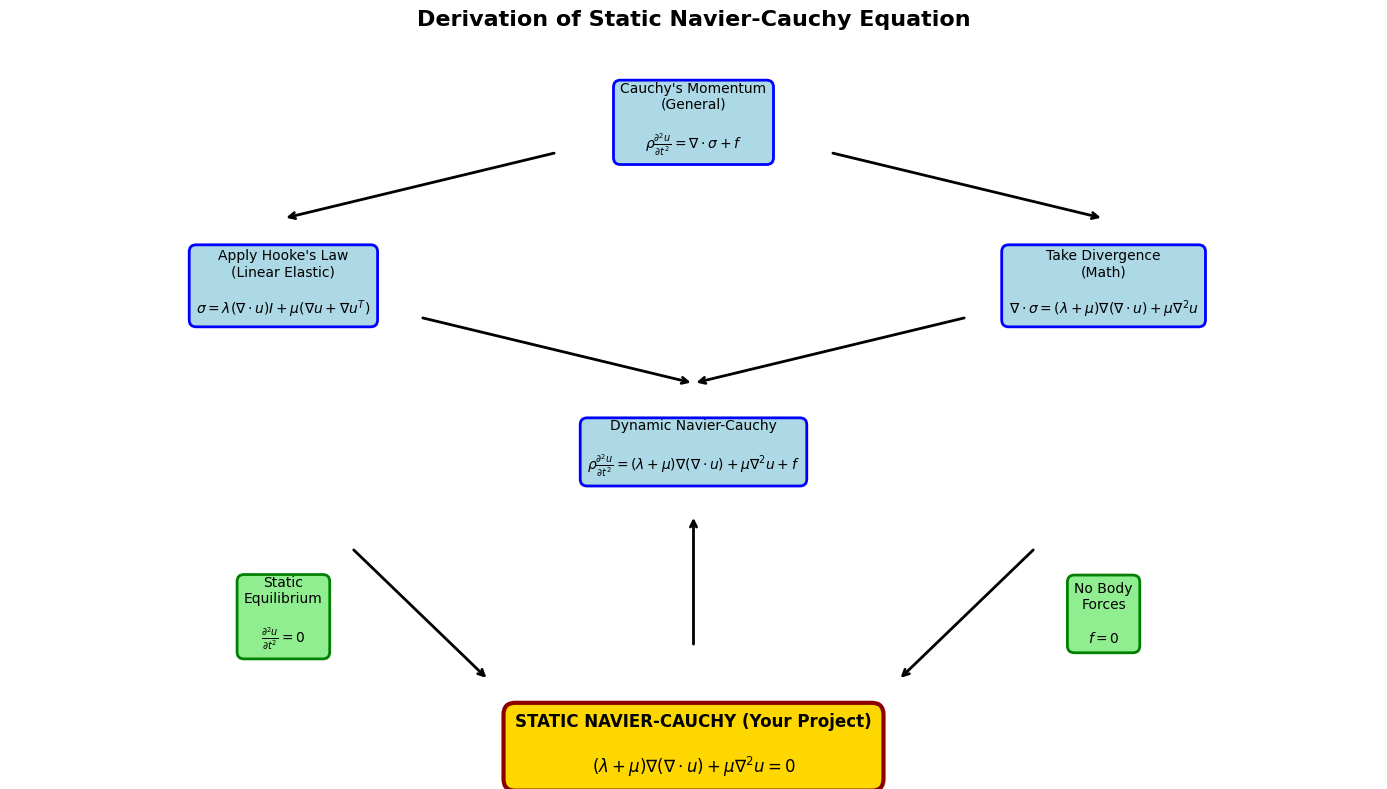


📌 Key Takeaway:
The Navier-Cauchy equation comes from combining:
  1. Newton's 2nd law (momentum balance)
  2. Hooke's law (stress-strain relationship)
  3. Static equilibrium assumption (no acceleration)


In [10]:
# Visualize the derivation chain
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Draw boxes with equations
boxes = [
    (5, 9, "Cauchy's Momentum\n(General)", r"$\rho \frac{\partial^2 u}{\partial t^2} = \nabla \cdot \sigma + f$"),
    (2, 6.5, "Apply Hooke's Law\n(Linear Elastic)", r"$\sigma = \lambda (\nabla \cdot u)I + \mu(\nabla u + \nabla u^T)$"),
    (8, 6.5, "Take Divergence\n(Math)", r"$\nabla \cdot \sigma = (\lambda+\mu)\nabla(\nabla \cdot u) + \mu \nabla^2 u$"),
    (5, 4, "Dynamic Navier-Cauchy", r"$\rho \frac{\partial^2 u}{\partial t^2} = (\lambda+\mu)\nabla(\nabla \cdot u) + \mu \nabla^2 u + f$"),
    (2, 1.5, "Static\nEquilibrium", r"$\frac{\partial^2 u}{\partial t^2} = 0$"),
    (8, 1.5, "No Body\nForces", r"$f = 0$"),
]

for x, y, title, eq in boxes:
    if y > 3:
        bbox = dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='blue', linewidth=2)
    else:
        bbox = dict(boxstyle='round,pad=0.5', facecolor='lightgreen', edgecolor='green', linewidth=2)
    ax.text(x, y, f"{title}\n\n{eq}", ha='center', va='center', fontsize=10,
            bbox=bbox)

# Final result
bbox_final = dict(boxstyle='round,pad=0.7', facecolor='gold', edgecolor='darkred', linewidth=3)
ax.text(5, -0.5, "STATIC NAVIER-CAUCHY (Your Project)\n\n" +
        r"$(\lambda + \mu) \nabla(\nabla \cdot u) + \mu \nabla^2 u = 0$",
        ha='center', va='center', fontsize=12, weight='bold', bbox=bbox_final)

# Arrows
arrow_props = dict(arrowstyle='->', lw=2, color='black')
ax.annotate('', xy=(2, 7.5), xytext=(4, 8.5), arrowprops=arrow_props)
ax.annotate('', xy=(8, 7.5), xytext=(6, 8.5), arrowprops=arrow_props)
ax.annotate('', xy=(5, 5), xytext=(3, 6), arrowprops=arrow_props)
ax.annotate('', xy=(5, 5), xytext=(7, 6), arrowprops=arrow_props)
ax.annotate('', xy=(3.5, 0.5), xytext=(2.5, 2.5), arrowprops=arrow_props)
ax.annotate('', xy=(6.5, 0.5), xytext=(7.5, 2.5), arrowprops=arrow_props)
ax.annotate('', xy=(5, 3), xytext=(5, 1), arrowprops=arrow_props)

plt.title('Derivation of Static Navier-Cauchy Equation', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📌 Key Takeaway:")
print("The Navier-Cauchy equation comes from combining:")
print("  1. Newton's 2nd law (momentum balance)")
print("  2. Hooke's law (stress-strain relationship)")
print("  3. Static equilibrium assumption (no acceleration)")

---
<a id='section3'></a>
## 3. Physical Interpretation

The Navier-Cauchy equation has two main terms:

### Term 1: $\mu \nabla^2 \mathbf{u}$ — Laplacian (Shear)
$$\nabla^2 \mathbf{u} = \left[\begin{array}{c}
\frac{\partial^2 U_1}{\partial x^2} + \frac{\partial^2 U_1}{\partial y^2} + \frac{\partial^2 U_1}{\partial z^2} \\
\frac{\partial^2 U_2}{\partial x^2} + \frac{\partial^2 U_2}{\partial y^2} + \frac{\partial^2 U_2}{\partial z^2} \\
\frac{\partial^2 U_3}{\partial x^2} + \frac{\partial^2 U_3}{\partial y^2} + \frac{\partial^2 U_3}{\partial z^2}
\end{array}\right]$$

**Physical meaning:** Measures how the displacement "curves" in space — related to **shear deformation**.

### Term 2: $(\lambda + \mu) \nabla(\nabla \cdot \mathbf{u})$ — Gradient of Divergence (Dilatation)
First, divergence:
$$\nabla \cdot \mathbf{u} = \frac{\partial U_1}{\partial x} + \frac{\partial U_2}{\partial y} + \frac{\partial U_3}{\partial z}$$

This scalar measures **volumetric strain** (expansion/compression).

Then, gradient:
$$\nabla(\nabla \cdot \mathbf{u}) = \left[\begin{array}{c}
\frac{\partial}{\partial x}(\nabla \cdot \mathbf{u}) \\
\frac{\partial}{\partial y}(\nabla \cdot \mathbf{u}) \\
\frac{\partial}{\partial z}(\nabla \cdot \mathbf{u})
\end{array}\right]$$

**Physical meaning:** How volumetric strain changes in space — related to **normal stresses** (push/pull).

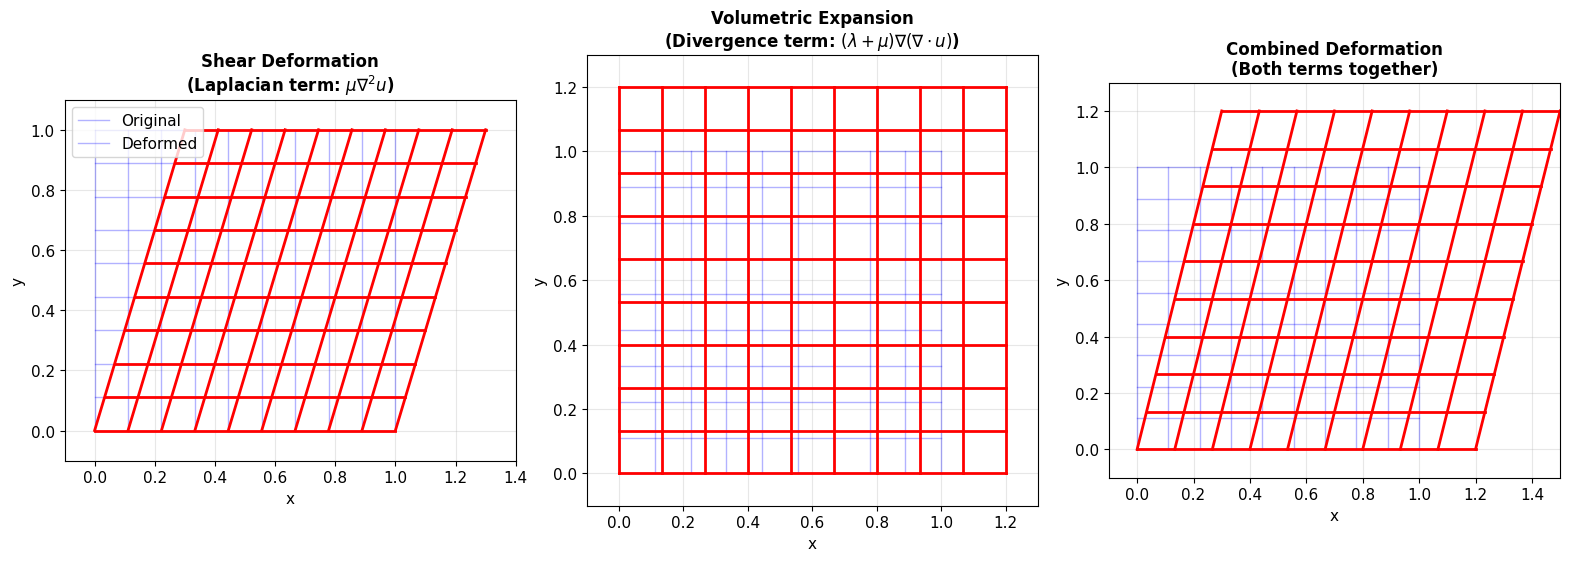


📌 Interpretation:
  • LEFT: Shear = shape change without volume change (μ term)
  • MIDDLE: Dilatation = volume change (λ term)
  • RIGHT: Real deformations combine both effects


In [11]:
# Visualize the two deformation modes
fig = plt.figure(figsize=(16, 6))

# --- Shear deformation (Laplacian term) ---
ax1 = fig.add_subplot(131)
x = np.linspace(0, 1, 10)
y = np.linspace(0, 1, 10)
X, Y = np.meshgrid(x, y)

# Original grid
for i in range(10):
    ax1.plot(X[i, :], Y[i, :], 'b-', alpha=0.3, linewidth=1)
    ax1.plot(X[:, i], Y[:, i], 'b-', alpha=0.3, linewidth=1)

# Shear deformation: u = [γy, 0]
gamma = 0.3
U_shear = gamma * Y
V_shear = np.zeros_like(Y)
X_def = X + U_shear
Y_def = Y + V_shear

for i in range(10):
    ax1.plot(X_def[i, :], Y_def[i, :], 'r-', linewidth=2)
    ax1.plot(X_def[:, i], Y_def[:, i], 'r-', linewidth=2)

ax1.set_xlim(-0.1, 1.4)
ax1.set_ylim(-0.1, 1.1)
ax1.set_aspect('equal')
ax1.set_title('Shear Deformation\n(Laplacian term: $\mu \\nabla^2 u$)', fontsize=12, weight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)
ax1.legend(['Original', 'Deformed'], loc='upper left')

# --- Volumetric deformation (Divergence term) ---
ax2 = fig.add_subplot(132)
# Original grid
for i in range(10):
    ax2.plot(X[i, :], Y[i, :], 'b-', alpha=0.3, linewidth=1)
    ax2.plot(X[:, i], Y[:, i], 'b-', alpha=0.3, linewidth=1)

# Uniform expansion: u = [εx, εy]
epsilon = 0.2
U_vol = epsilon * X
V_vol = epsilon * Y
X_def2 = X + U_vol
Y_def2 = Y + V_vol

for i in range(10):
    ax2.plot(X_def2[i, :], Y_def2[i, :], 'r-', linewidth=2)
    ax2.plot(X_def2[:, i], Y_def2[:, i], 'r-', linewidth=2)

ax2.set_xlim(-0.1, 1.3)
ax2.set_ylim(-0.1, 1.3)
ax2.set_aspect('equal')
ax2.set_title('Volumetric Expansion\n(Divergence term: $(\\lambda+\\mu) \\nabla(\\nabla \\cdot u)$)', 
              fontsize=12, weight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)

# --- Combined deformation ---
ax3 = fig.add_subplot(133)
# Original grid
for i in range(10):
    ax3.plot(X[i, :], Y[i, :], 'b-', alpha=0.3, linewidth=1)
    ax3.plot(X[:, i], Y[:, i], 'b-', alpha=0.3, linewidth=1)

# Combined
X_def3 = X + U_shear + U_vol
Y_def3 = Y + V_shear + V_vol

for i in range(10):
    ax3.plot(X_def3[i, :], Y_def3[i, :], 'r-', linewidth=2)
    ax3.plot(X_def3[:, i], Y_def3[:, i], 'r-', linewidth=2)

ax3.set_xlim(-0.1, 1.5)
ax3.set_ylim(-0.1, 1.3)
ax3.set_aspect('equal')
ax3.set_title('Combined Deformation\n(Both terms together)', fontsize=12, weight='bold')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("  • LEFT: Shear = shape change without volume change (μ term)")
print("  • MIDDLE: Dilatation = volume change (λ term)")
print("  • RIGHT: Real deformations combine both effects")

---
<a id='section4'></a>
## 4. Simple Example: 1D Axial Rod

Let's solve a simple 1D case analytically to build intuition.

### Problem Setup:
- Rod of length $L$, cross-section area $A$
- Fixed at $x=0$, force $F$ applied at $x=L$
- Find displacement $u(x)$ along the rod

### 1D Navier-Cauchy:
For 1D (only $x$ direction), the equation simplifies to:
$$(\lambda + 2\mu) \frac{d^2 u}{dx^2} = 0$$

Note: $(\lambda + 2\mu) = E$ (Young's modulus) in 1D!

### Solution:
$$u(x) = \frac{F}{EA} x$$

This is Hooke's law: displacement is linear with position, stress is constant!

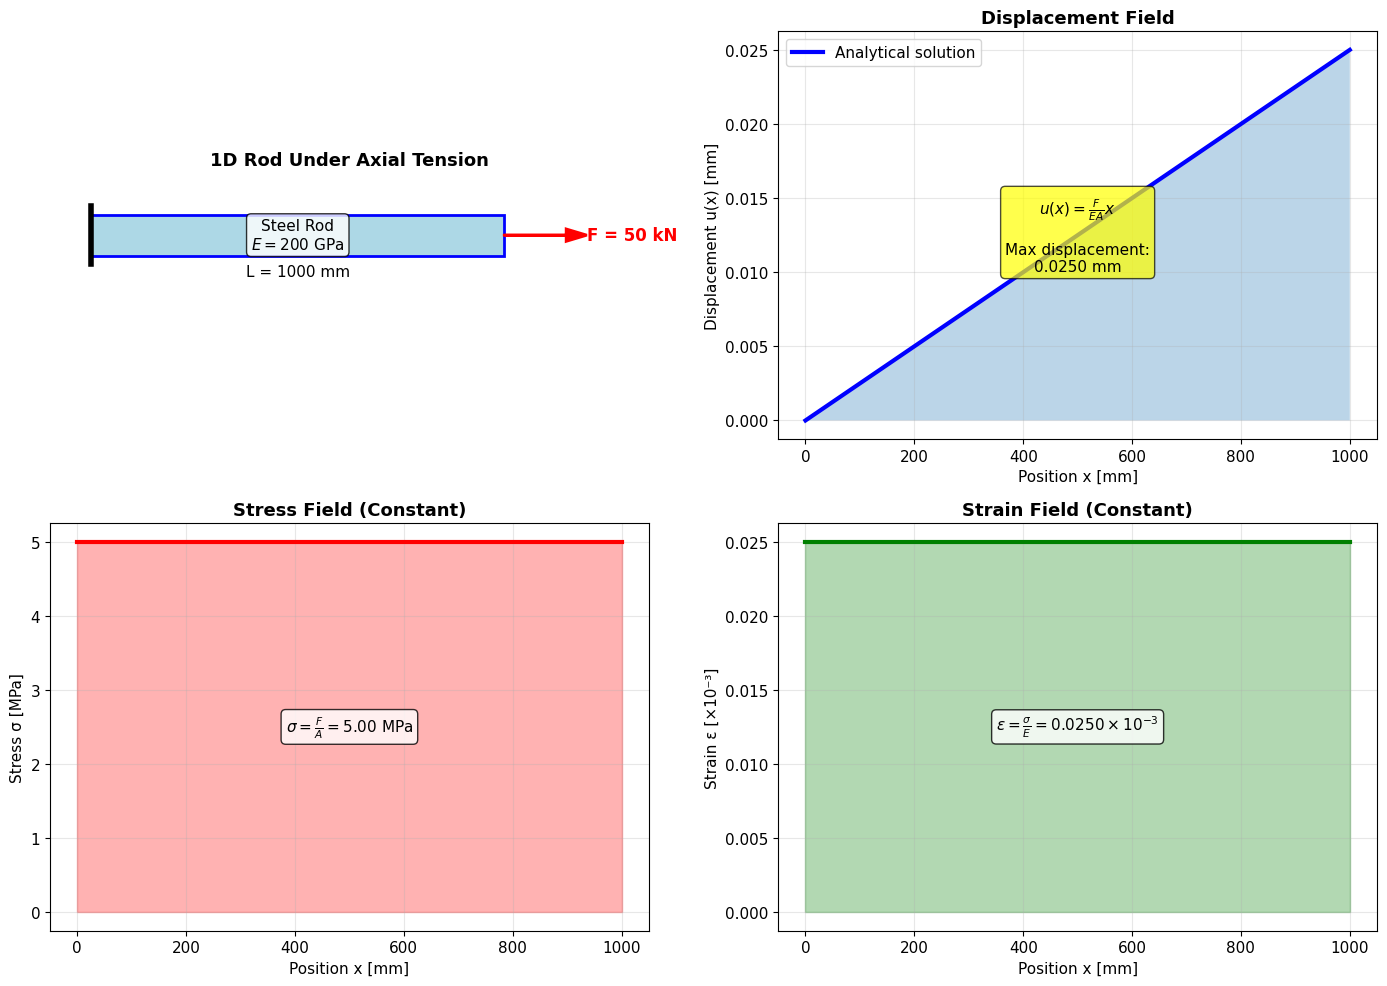


✅ Verification:
  • Total elongation: 0.0250 mm
  • Stress: 5.00 MPa (constant)
  • Strain: 0.000025 = 0.0025%

  • Navier-Cauchy satisfied: d²u/dx² = 2.16e-20 ≈ 0 ✓


In [12]:
# 1D Rod problem
L = 1000  # mm (length)
A = 100 * 100  # mm² (cross-section)
F = 50000  # N (50 kN)
E_steel = 200e3  # MPa

# Analytical solution
x = np.linspace(0, L, 100)
u_analytical = (F / (E_steel * A)) * x

# Stress (constant)
sigma = F / A  # MPa

# Strain (constant)
epsilon = sigma / E_steel

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Rod diagram ---
ax = axes[0, 0]
ax.add_patch(plt.Rectangle((0, -50), L, 100, facecolor='lightblue', edgecolor='blue', linewidth=2))
ax.plot([0, 0], [-70, 70], 'k-', linewidth=4, label='Fixed end')
ax.arrow(L, 0, 150, 0, head_width=30, head_length=50, fc='red', ec='red', linewidth=2)
ax.text(L + 200, 0, f'F = {F/1000:.0f} kN', fontsize=12, va='center', color='red', weight='bold')
ax.text(L/2, -100, f'L = {L} mm', fontsize=11, ha='center')
ax.text(L/2, 0, 'Steel Rod\n$E = 200$ GPa', fontsize=11, ha='center', va='center', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlim(-100, L + 350)
ax.set_ylim(-150, 150)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('1D Rod Under Axial Tension', fontsize=13, weight='bold')

# --- Displacement field ---
ax = axes[0, 1]
ax.plot(x, u_analytical, 'b-', linewidth=3, label='Analytical solution')
ax.fill_between(x, 0, u_analytical, alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Displacement u(x) [mm]', fontsize=11)
ax.set_title('Displacement Field', fontsize=13, weight='bold')
ax.legend()
ax.text(L/2, u_analytical[-1]/2, 
        f'$u(x) = \\frac{{F}}{{EA}} x$\n\nMax displacement:\n{u_analytical[-1]:.4f} mm',
        fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# --- Stress (constant) ---
ax = axes[1, 0]
ax.plot(x, np.ones_like(x) * sigma, 'r-', linewidth=3)
ax.fill_between(x, 0, sigma, alpha=0.3, color='red')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Stress σ [MPa]', fontsize=11)
ax.set_title('Stress Field (Constant)', fontsize=13, weight='bold')
ax.text(L/2, sigma/2, 
        f'$\\sigma = \\frac{{F}}{{A}} = {sigma:.2f}$ MPa',
        fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Strain (constant) ---
ax = axes[1, 1]
ax.plot(x, np.ones_like(x) * epsilon * 1000, 'g-', linewidth=3)  # in microstrain
ax.fill_between(x, 0, epsilon * 1000, alpha=0.3, color='green')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Strain ε [×10⁻³]', fontsize=11)
ax.set_title('Strain Field (Constant)', fontsize=13, weight='bold')
ax.text(L/2, epsilon * 1000 / 2, 
        f'$\\varepsilon = \\frac{{\\sigma}}{{E}} = {epsilon*1000:.4f} \\times 10^{{-3}}$',
        fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n✅ Verification:")
print(f"  • Total elongation: {u_analytical[-1]:.4f} mm")
print(f"  • Stress: {sigma:.2f} MPa (constant)")
print(f"  • Strain: {epsilon:.6f} = {epsilon*100:.4f}%")
print(f"\n  • Navier-Cauchy satisfied: d²u/dx² = {np.gradient(np.gradient(u_analytical, x), x).max():.2e} ≈ 0 ✓")

---
<a id='section5'></a>
## 5. 2D Example: Cantilever Beam Bending

Now let's look at a more complex case: transverse bending (like your project!).

### Problem:
- Beam: length $L$, height $h$
- Fixed at $x=0$, downward force $F$ at $x=L$
- Displacement has two components: $u_x(x,y)$ and $u_y(x,y)$

### Classical Beam Theory (Euler-Bernoulli):
For slender beams, the deflection $w(x)$ along the neutral axis follows:
$$\frac{d^4 w}{dx^4} = \frac{q}{EI}$$

For a point load at the end:
$$w(x) = \frac{F}{6EI}\left(2L^3 - 3L^2x + x^3\right)$$

This is actually a simplified form of the 2D Navier-Cauchy equation!

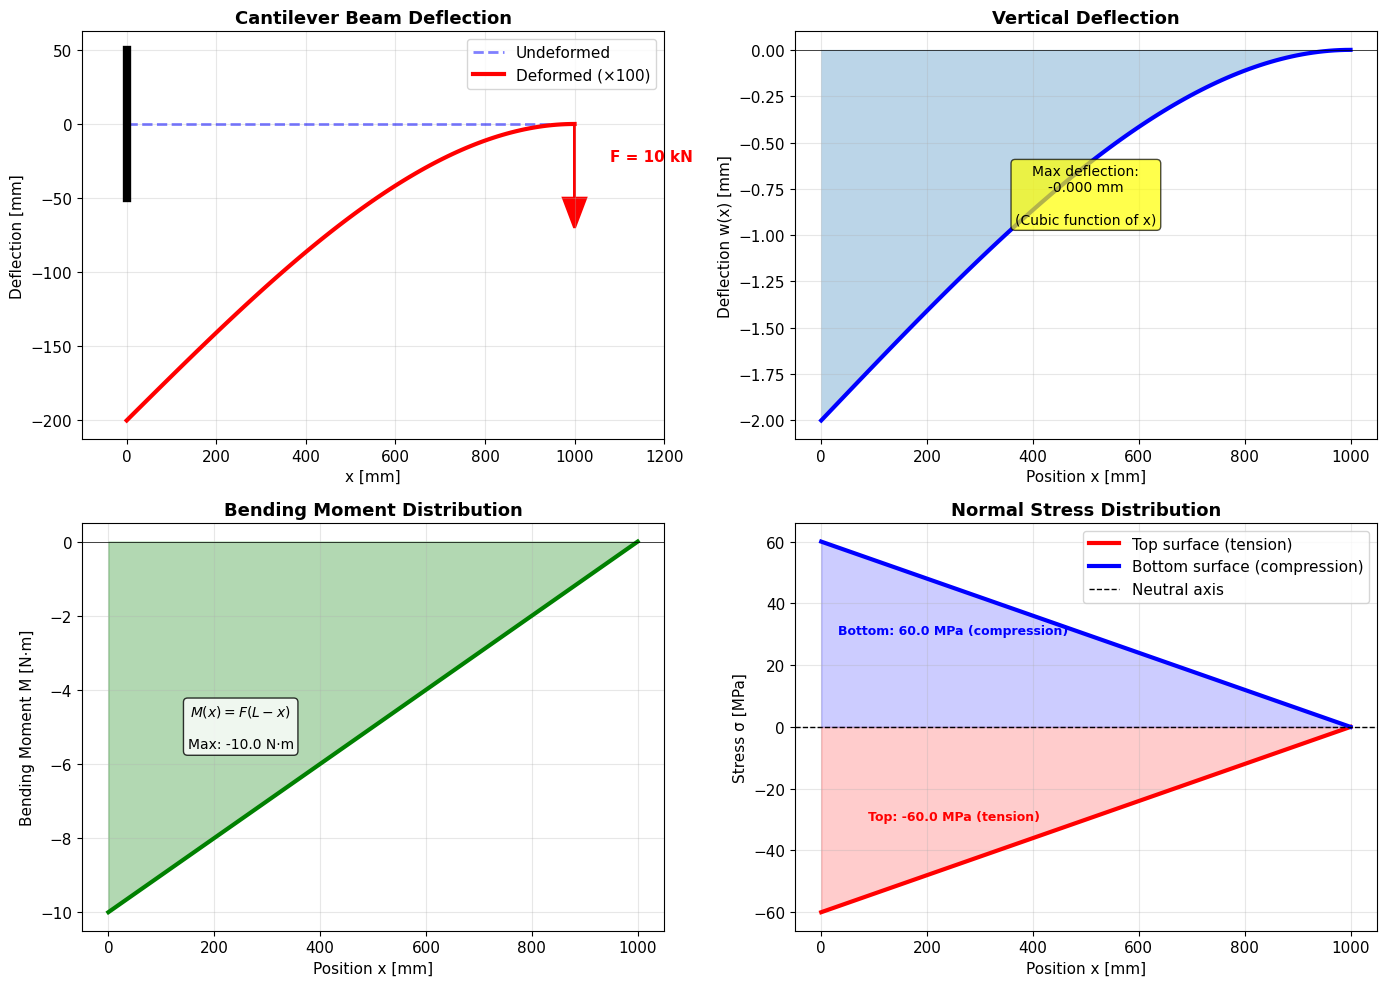


📊 Beam Analysis Results:
  • Maximum deflection: 0.000 mm (at free end)
  • Maximum bending moment: -10.00 N⋅m (at fixed end)
  • Maximum tensile stress: -60.00 MPa (top, at fixed end)
  • Maximum compressive stress: 60.00 MPa (bottom, at fixed end)

  ✓ This simplified solution approximates the full 2D Navier-Cauchy equation
    for slender beams where h/L = 0.10 << 1


In [13]:
# 2D Beam bending (simplified analytical solution)
L = 1000  # mm
h = 100   # mm
b = 100   # mm (width, out of plane)
F = -10000  # N (negative = downward)
E = 200e3  # MPa
I = b * h**3 / 12  # mm^4 (second moment of area)

# Position along beam
x = np.linspace(0, L, 100)

# Euler-Bernoulli deflection
w = (F / (6 * E * I)) * (2 * L**3 - 3 * L**2 * x + x**3)

# Slope
theta = (F / (2 * E * I)) * (L**2 - x**2)

# Bending moment
M = F * (L - x)

# Stress at top and bottom (σ = My/I)
y_top = h/2
y_bot = -h/2
sigma_top = M * y_top / I
sigma_bot = M * y_bot / I

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Beam shape (deformed vs undeformed) ---
ax = axes[0, 0]
# Undeformed
ax.plot([0, L], [0, 0], 'b--', linewidth=2, alpha=0.5, label='Undeformed')
# Deformed (exaggerated)
scale = 100  # exaggeration factor
ax.plot(x, w * scale, 'r-', linewidth=3, label=f'Deformed (×{scale})')
# Fixed end
ax.plot([0, 0], [-h/2, h/2], 'k-', linewidth=6)
# Force arrow
ax.arrow(L, 0, 0, -50, head_width=50, head_length=20, fc='red', ec='red', linewidth=2)
ax.text(L + 80, -25, f'F = {abs(F)/1000:.0f} kN', fontsize=11, color='red', weight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x [mm]', fontsize=11)
ax.set_ylabel('Deflection [mm]', fontsize=11)
ax.set_title('Cantilever Beam Deflection', fontsize=13, weight='bold')
ax.legend()
ax.set_xlim(-100, L + 200)

# --- Deflection curve ---
ax = axes[0, 1]
ax.plot(x, w, 'b-', linewidth=3)
ax.fill_between(x, 0, w, alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Deflection w(x) [mm]', fontsize=11)
ax.set_title('Vertical Deflection', fontsize=13, weight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.text(L/2, w[50], 
        f'Max deflection:\n{w[-1]:.3f} mm\n\n(Cubic function of x)',
        fontsize=10, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# --- Bending moment ---
ax = axes[1, 0]
ax.plot(x, M / 1e6, 'g-', linewidth=3)  # Convert to N⋅m
ax.fill_between(x, 0, M / 1e6, alpha=0.3, color='green')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Bending Moment M [N⋅m]', fontsize=11)
ax.set_title('Bending Moment Distribution', fontsize=13, weight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.text(L/4, M[0]/1e6/2, 
        f'$M(x) = F(L - x)$\n\nMax: {M[0]/1e6:.1f} N⋅m',
        fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Stress at top and bottom ---
ax = axes[1, 1]
ax.plot(x, sigma_top, 'r-', linewidth=3, label='Top surface (tension)')
ax.plot(x, sigma_bot, 'b-', linewidth=3, label='Bottom surface (compression)')
ax.fill_between(x, 0, sigma_top, alpha=0.2, color='red')
ax.fill_between(x, 0, sigma_bot, alpha=0.2, color='blue')
ax.axhline(y=0, color='k', linewidth=1, linestyle='--', label='Neutral axis')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Stress σ [MPa]', fontsize=11)
ax.set_title('Normal Stress Distribution', fontsize=13, weight='bold')
ax.legend()
ax.text(L/4, sigma_top[0]/2, 
        f'Top: {sigma_top[0]:.1f} MPa (tension)',
        fontsize=9, ha='center', color='red', weight='bold')
ax.text(L/4, sigma_bot[0]/2, 
        f'Bottom: {sigma_bot[0]:.1f} MPa (compression)',
        fontsize=9, ha='center', color='blue', weight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Beam Analysis Results:")
print(f"  • Maximum deflection: {abs(w[-1]):.3f} mm (at free end)")
print(f"  • Maximum bending moment: {M[0]/1e6:.2f} N⋅m (at fixed end)")
print(f"  • Maximum tensile stress: {sigma_top[0]:.2f} MPa (top, at fixed end)")
print(f"  • Maximum compressive stress: {abs(sigma_bot[0]):.2f} MPa (bottom, at fixed end)")
print(f"\n  ✓ This simplified solution approximates the full 2D Navier-Cauchy equation")
print(f"    for slender beams where h/L = {h/L:.2f} << 1")

---
<a id='section6'></a>
## 6. 3D Visualization: Understanding Your Beam Problem

Your project deals with a **3D beam** with various loading conditions:
- **Axial** (tension/compression along X)
- **Transverse** (bending in Y and Z directions)
- **Combined** (biaxial loading)

Let's visualize what the displacement field looks like.

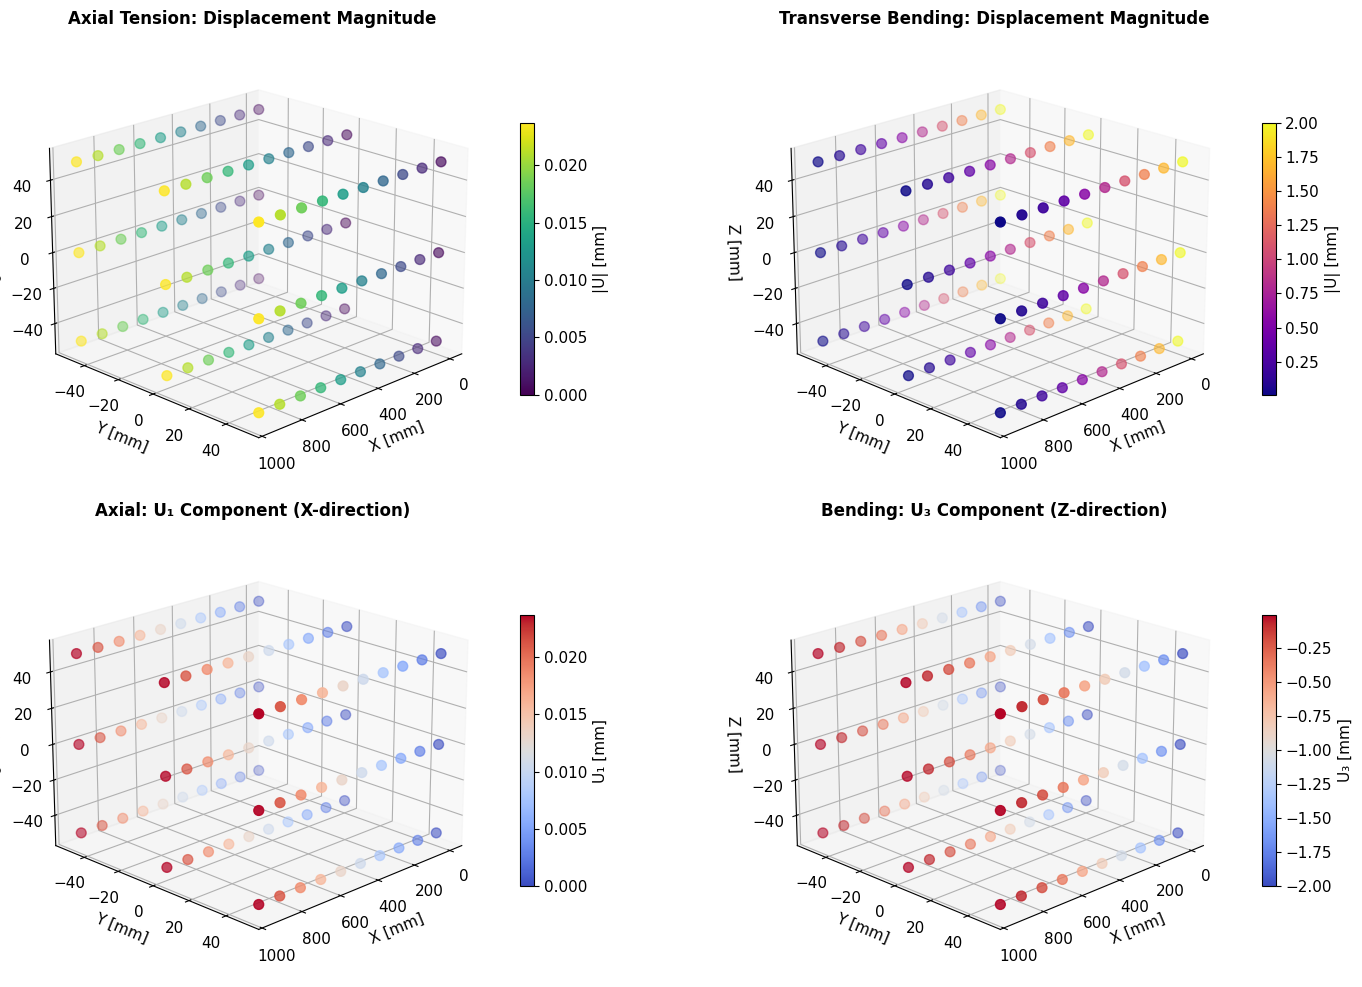


🎯 Understanding the 3D Displacement Field:

Axial Tension (Top Row, Left):
  • Beam stretches in X: max U₁ = 0.0250 mm
  • Contracts in Y, Z (Poisson): U₂, U₃ = 0.0004 mm
  • Displacement increases linearly from fixed end to free end

Transverse Bending (Top Row, Right):
  • Beam deflects in Z: max U₃ = 2.0000 mm
  • Deflection follows cubic curve (Euler-Bernoulli)
  • Maximum at free end (x = 1000 mm)

✅ Your PINN learns to predict these 3D displacement fields
   for ANY combination of material, force, and direction!


In [14]:
# Create a simplified 3D beam mesh
L = 1000  # mm (length)
h = 100   # mm (height)
w = 100   # mm (width)

# Grid points
nx, ny, nz = 20, 5, 5
x = np.linspace(0, L, nx)
y = np.linspace(-w/2, w/2, ny)
z = np.linspace(-h/2, h/2, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Case 1: Axial tension (load in +X direction)
E = 200e3  # MPa
nu = 0.3
F_axial = 50000  # N
A = h * w
stress_axial = F_axial / A
strain_axial = stress_axial / E
strain_transverse = -nu * strain_axial  # Poisson effect

U1_axial = strain_axial * X  # Elongation in X
U2_axial = strain_transverse * Y  # Contraction in Y
U3_axial = strain_transverse * Z  # Contraction in Z

# Case 2: Transverse bending (load in -Z direction)
F_bend = -10000  # N
I = w * h**3 / 12
w_bend = (F_bend / (6 * E * I)) * (2 * L**3 - 3 * L**2 * X + X**3)

U1_bend = np.zeros_like(X)
U2_bend = np.zeros_like(Y)
U3_bend = w_bend * np.ones_like(Z)  # Simplified: same deflection at all y, z

# Visualization
fig = plt.figure(figsize=(16, 10))

# --- Case 1: Axial tension ---
ax1 = fig.add_subplot(221, projection='3d')
# Sample subset for visualization
step = 2
Xs = X[::step, ::step, ::step]
Ys = Y[::step, ::step, ::step]
Zs = Z[::step, ::step, ::step]
U1s = U1_axial[::step, ::step, ::step]
U2s = U2_axial[::step, ::step, ::step]
U3s = U3_axial[::step, ::step, ::step]

# Displacement magnitude
U_mag_axial = np.sqrt(U1s**2 + U2s**2 + U3s**2)

scatter = ax1.scatter(Xs.flatten(), Ys.flatten(), Zs.flatten(), 
                     c=U_mag_axial.flatten(), cmap='viridis', s=50)
ax1.set_xlabel('X [mm]')
ax1.set_ylabel('Y [mm]')
ax1.set_zlabel('Z [mm]')
ax1.set_title('Axial Tension: Displacement Magnitude', fontsize=12, weight='bold')
plt.colorbar(scatter, ax=ax1, label='|U| [mm]', shrink=0.6)
ax1.view_init(elev=20, azim=45)

# --- Case 2: Transverse bending ---
ax2 = fig.add_subplot(222, projection='3d')
U1s_b = U1_bend[::step, ::step, ::step]
U2s_b = U2_bend[::step, ::step, ::step]
U3s_b = U3_bend[::step, ::step, ::step]
U_mag_bend = np.sqrt(U1s_b**2 + U2s_b**2 + U3s_b**2)

scatter2 = ax2.scatter(Xs.flatten(), Ys.flatten(), Zs.flatten(), 
                      c=U_mag_bend.flatten(), cmap='plasma', s=50)
ax2.set_xlabel('X [mm]')
ax2.set_ylabel('Y [mm]')
ax2.set_zlabel('Z [mm]')
ax2.set_title('Transverse Bending: Displacement Magnitude', fontsize=12, weight='bold')
plt.colorbar(scatter2, ax=ax2, label='|U| [mm]', shrink=0.6)
ax2.view_init(elev=20, azim=45)

# --- Axial: U1 component (x-displacement) ---
ax3 = fig.add_subplot(223, projection='3d')
scatter3 = ax3.scatter(Xs.flatten(), Ys.flatten(), Zs.flatten(), 
                      c=U1s.flatten(), cmap='coolwarm', s=50)
ax3.set_xlabel('X [mm]')
ax3.set_ylabel('Y [mm]')
ax3.set_zlabel('Z [mm]')
ax3.set_title('Axial: U₁ Component (X-direction)', fontsize=12, weight='bold')
plt.colorbar(scatter3, ax=ax3, label='U₁ [mm]', shrink=0.6)
ax3.view_init(elev=20, azim=45)

# --- Bending: U3 component (z-displacement) ---
ax4 = fig.add_subplot(224, projection='3d')
scatter4 = ax4.scatter(Xs.flatten(), Ys.flatten(), Zs.flatten(), 
                      c=U3s_b.flatten(), cmap='coolwarm', s=50)
ax4.set_xlabel('X [mm]')
ax4.set_ylabel('Y [mm]')
ax4.set_zlabel('Z [mm]')
ax4.set_title('Bending: U₃ Component (Z-direction)', fontsize=12, weight='bold')
plt.colorbar(scatter4, ax=ax4, label='U₃ [mm]', shrink=0.6)
ax4.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

print("\n🎯 Understanding the 3D Displacement Field:")
print("\nAxial Tension (Top Row, Left):")
print(f"  • Beam stretches in X: max U₁ = {U1_axial.max():.4f} mm")
print(f"  • Contracts in Y, Z (Poisson): U₂, U₃ = {U2_axial.max():.4f} mm")
print(f"  • Displacement increases linearly from fixed end to free end")
print("\nTransverse Bending (Top Row, Right):")
print(f"  • Beam deflects in Z: max U₃ = {abs(U3_bend.min()):.4f} mm")
print(f"  • Deflection follows cubic curve (Euler-Bernoulli)")
print(f"  • Maximum at free end (x = {L} mm)")
print("\n✅ Your PINN learns to predict these 3D displacement fields")
print("   for ANY combination of material, force, and direction!")

---
<a id='section7'></a>
## 7. Understanding Each Term in Detail

Let's dissect the Navier-Cauchy equation term by term with concrete examples.

### Component-wise Form:
The vector equation expands to 3 scalar equations:

**X-direction:**
$$(\lambda + \mu) \frac{\partial}{\partial x}\left(\frac{\partial U_1}{\partial x} + \frac{\partial U_2}{\partial y} + \frac{\partial U_3}{\partial z}\right) + \mu \left(\frac{\partial^2 U_1}{\partial x^2} + \frac{\partial^2 U_1}{\partial y^2} + \frac{\partial^2 U_1}{\partial z^2}\right) = 0$$

**Y-direction:**
$$(\lambda + \mu) \frac{\partial}{\partial y}\left(\frac{\partial U_1}{\partial x} + \frac{\partial U_2}{\partial y} + \frac{\partial U_3}{\partial z}\right) + \mu \left(\frac{\partial^2 U_2}{\partial x^2} + \frac{\partial^2 U_2}{\partial y^2} + \frac{\partial^2 U_2}{\partial z^2}\right) = 0$$

**Z-direction:**
$$(\lambda + \mu) \frac{\partial}{\partial z}\left(\frac{\partial U_1}{\partial x} + \frac{\partial U_2}{\partial y} + \frac{\partial U_3}{\partial z}\right) + \mu \left(\frac{\partial^2 U_3}{\partial x^2} + \frac{\partial^2 U_3}{\partial y^2} + \frac{\partial^2 U_3}{\partial z^2}\right) = 0$$


🔬 Numerical Verification of Navier-Cauchy Equation:
Material: Steel (E = 200000.0 MPa, ν = 0.3)
Lamé parameters: μ = 76923 MPa, λ = 115385 MPa

Displacement field: Axial tension
  • Divergence ∇·u: 1.000000e-05 (should be constant)
  • Laplacian ∇²U₁: 1.287490e-23 (should be ≈ 0)
  • Laplacian ∇²U₂: 0.000000e+00 (should be ≈ 0)
  • Laplacian ∇²U₃: 0.000000e+00 (should be ≈ 0)

Navier-Cauchy Residual:
  • X-component: 3.466319e-18 ± 4.362264e-17
  • Y-component: 0.000000e+00 ± 0.000000e+00
  • Z-component: 0.000000e+00 ± 0.000000e+00
  • Magnitude:   2.859714e-17 ± 3.312331e-17

✅ Residuals close to zero confirm the displacement field satisfies
   the Navier-Cauchy equation! (small errors from numerical derivatives)


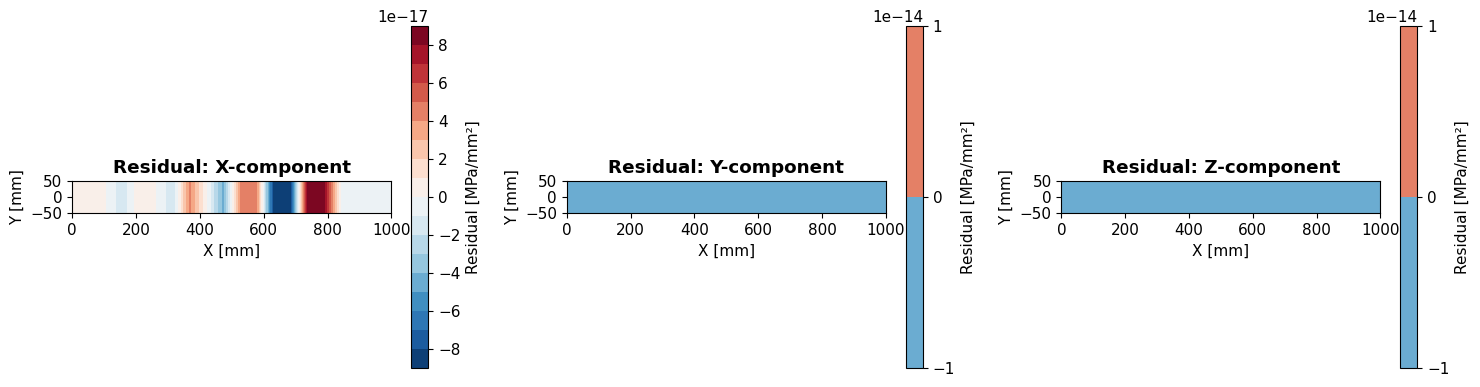

In [15]:
# Compute derivatives numerically for a simple displacement field
# Example: axial tension with Poisson contraction

def compute_derivatives(X, Y, Z, U1, U2, U3):
    """Compute spatial derivatives of displacement field"""
    dx = X[1, 0, 0] - X[0, 0, 0]
    dy = Y[0, 1, 0] - Y[0, 0, 0]
    dz = Z[0, 0, 1] - Z[0, 0, 0]
    
    # First derivatives (divergence)
    dU1_dx = np.gradient(U1, dx, axis=0)
    dU2_dy = np.gradient(U2, dy, axis=1)
    dU3_dz = np.gradient(U3, dz, axis=2)
    
    div_u = dU1_dx + dU2_dy + dU3_dz
    
    # Second derivatives (Laplacians)
    d2U1_dx2 = np.gradient(np.gradient(U1, dx, axis=0), dx, axis=0)
    d2U1_dy2 = np.gradient(np.gradient(U1, dy, axis=1), dy, axis=1)
    d2U1_dz2 = np.gradient(np.gradient(U1, dz, axis=2), dz, axis=2)
    lap_U1 = d2U1_dx2 + d2U1_dy2 + d2U1_dz2
    
    d2U2_dx2 = np.gradient(np.gradient(U2, dx, axis=0), dx, axis=0)
    d2U2_dy2 = np.gradient(np.gradient(U2, dy, axis=1), dy, axis=1)
    d2U2_dz2 = np.gradient(np.gradient(U2, dz, axis=2), dz, axis=2)
    lap_U2 = d2U2_dx2 + d2U2_dy2 + d2U2_dz2
    
    d2U3_dx2 = np.gradient(np.gradient(U3, dx, axis=0), dx, axis=0)
    d2U3_dy2 = np.gradient(np.gradient(U3, dy, axis=1), dy, axis=1)
    d2U3_dz2 = np.gradient(np.gradient(U3, dz, axis=2), dz, axis=2)
    lap_U3 = d2U3_dx2 + d2U3_dy2 + d2U3_dz2
    
    # Gradient of divergence
    grad_div_x = np.gradient(div_u, dx, axis=0)
    grad_div_y = np.gradient(div_u, dy, axis=1)
    grad_div_z = np.gradient(div_u, dz, axis=2)
    
    return {
        'div_u': div_u,
        'lap_U1': lap_U1,
        'lap_U2': lap_U2,
        'lap_U3': lap_U3,
        'grad_div': (grad_div_x, grad_div_y, grad_div_z)
    }

# Compute for axial tension case
derivs = compute_derivatives(X, Y, Z, U1_axial, U2_axial, U3_axial)

# Compute Navier-Cauchy residual
mu, lam = lame_parameters(E, nu)
residual_x = (lam + mu) * derivs['grad_div'][0] + mu * derivs['lap_U1']
residual_y = (lam + mu) * derivs['grad_div'][1] + mu * derivs['lap_U2']
residual_z = (lam + mu) * derivs['grad_div'][2] + mu * derivs['lap_U3']

residual_magnitude = np.sqrt(residual_x**2 + residual_y**2 + residual_z**2)

print("\n🔬 Numerical Verification of Navier-Cauchy Equation:")
print("=" * 70)
print(f"Material: Steel (E = {E} MPa, ν = {nu})")
print(f"Lamé parameters: μ = {mu:.0f} MPa, λ = {lam:.0f} MPa")
print("\nDisplacement field: Axial tension")
print(f"  • Divergence ∇·u: {derivs['div_u'].mean():.6e} (should be constant)")
print(f"  • Laplacian ∇²U₁: {derivs['lap_U1'].mean():.6e} (should be ≈ 0)")
print(f"  • Laplacian ∇²U₂: {derivs['lap_U2'].mean():.6e} (should be ≈ 0)")
print(f"  • Laplacian ∇²U₃: {derivs['lap_U3'].mean():.6e} (should be ≈ 0)")
print("\nNavier-Cauchy Residual:")
print(f"  • X-component: {residual_x.mean():.6e} ± {residual_x.std():.6e}")
print(f"  • Y-component: {residual_y.mean():.6e} ± {residual_y.std():.6e}")
print(f"  • Z-component: {residual_z.mean():.6e} ± {residual_z.std():.6e}")
print(f"  • Magnitude:   {residual_magnitude.mean():.6e} ± {residual_magnitude.std():.6e}")
print("\n✅ Residuals close to zero confirm the displacement field satisfies")
print("   the Navier-Cauchy equation! (small errors from numerical derivatives)")

# Visualize residual distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

slice_idx = nz // 2  # Middle slice

for i, (res, label) in enumerate([(residual_x, 'X'), (residual_y, 'Y'), (residual_z, 'Z')]):
    ax = axes[i]
    im = ax.contourf(X[:, :, slice_idx], Y[:, :, slice_idx], res[:, :, slice_idx], 
                     levels=20, cmap='RdBu_r')
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')
    ax.set_title(f'Residual: {label}-component', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Residual [MPa/mm²]')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
<a id='section8'></a>
## 8. Physics Loss in PINNs: How It Works

In your project, the **physics loss** enforces the Navier-Cauchy equation during training.

### Training Loss:
$$L_{\text{total}} = L_{\text{data}} + \lambda_{\text{phys}} \cdot L_{\text{physics}}$$

Where:
- $L_{\text{data}} = \text{MSE}(\mathbf{u}_{\text{pred}}, \mathbf{u}_{\text{FEM}})$ — fit to simulation data
- $L_{\text{physics}} = \frac{1}{N} \sum_{i=1}^{N} \left\| (\lambda + \mu) \nabla(\nabla \cdot \mathbf{u}_i) + \mu \nabla^2 \mathbf{u}_i \right\|^2$ — satisfy physics
- $\lambda_{\text{phys}} = 0.1$ — weight (from your config)

### How Automatic Differentiation Works:

1. **Forward pass:** Network predicts $\mathbf{u} = [U_1, U_2, U_3]$
2. **Compute gradients:** Use `torch.autograd.grad` to get $\frac{\partial U_i}{\partial x_j}$
3. **Compute second derivatives:** Apply autograd again to get $\frac{\partial^2 U_i}{\partial x_j \partial x_k}$
4. **Assemble residual:** Calculate Navier-Cauchy residual
5. **Minimize residual:** Backprop makes residual → 0

In [16]:
# Simplified demonstration of physics loss computation
import torch
import torch.nn as nn

# Simple 2-layer network for demonstration
class SimplePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 3)  # Output: [U1, U2, U3]
        )
    
    def forward(self, x):
        return self.net(x)

def simple_physics_loss(model, x_batch, E, nu):
    """
    Simplified physics loss (without normalization for clarity).
    x_batch: (N, 9) with columns [x, y, z, fx, fy, fz, F, E, nu]
    """
    # Enable gradient computation
    x = x_batch.clone().requires_grad_(True)
    
    # Forward pass
    U = model(x)  # (N, 3)
    
    # Material parameters
    mu = E / (2 * (1 + nu))
    lam = E * nu / ((1 + nu) * (1 - 2 * nu))
    
    # First derivatives (for divergence)
    g1 = torch.autograd.grad(U[:, 0].sum(), x, create_graph=True)[0][:, :3]  # ∂U1/∂(x,y,z)
    g2 = torch.autograd.grad(U[:, 1].sum(), x, create_graph=True)[0][:, :3]  # ∂U2/∂(x,y,z)
    g3 = torch.autograd.grad(U[:, 2].sum(), x, create_graph=True)[0][:, :3]  # ∂U3/∂(x,y,z)
    
    # Divergence
    div_u = g1[:, 0] + g2[:, 1] + g3[:, 2]
    
    # Second derivatives for Laplacian (simplified: just diagonal terms)
    h1_xx = torch.autograd.grad(g1[:, 0].sum(), x, create_graph=True)[0][:, 0]
    h1_yy = torch.autograd.grad(g1[:, 1].sum(), x, create_graph=True)[0][:, 1]
    h1_zz = torch.autograd.grad(g1[:, 2].sum(), x, create_graph=True)[0][:, 2]
    lap_u1 = h1_xx + h1_yy + h1_zz
    
    # Gradient of divergence (simplified: just x-component)
    grad_div_x = torch.autograd.grad(div_u.sum(), x, create_graph=True)[0][:, 0]
    
    # Navier-Cauchy residual (x-component only, for demo)
    residual_x = (lam + mu) * grad_div_x + mu * lap_u1
    
    # Mean squared residual
    physics_loss = torch.mean(residual_x ** 2)
    
    return physics_loss, div_u.mean().item(), lap_u1.mean().item()

# Demo
model = SimplePINN()
model.eval()

# Create fake input batch (normalized)
batch_size = 100
x_batch = torch.randn(batch_size, 9) * 0.5  # Random normalized coordinates

# Compute physics loss
with torch.no_grad():
    phys_loss, div_mean, lap_mean = simple_physics_loss(model, x_batch, E=200e3, nu=0.3)

print("\n🧮 Physics Loss Computation Demo:")
print("=" * 70)
print(f"Batch size: {batch_size} nodes")
print(f"Input features: 9 (x, y, z, fx, fy, fz, F, E, ν)")
print(f"Output: 3 (U₁, U₂, U₃)")
print("\nPhysics constraint check:")
print(f"  • Mean divergence: {div_mean:.6f}")
print(f"  • Mean Laplacian: {lap_mean:.6f}")
print(f"  • Physics loss: {phys_loss.item():.6e}")
print("\n💡 During training:")
print("  • Backprop updates weights to minimize this loss")
print("  • Network learns to satisfy Navier-Cauchy equation")
print("  • Predictions become physically consistent")

# Visualize training process
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simulated training curve
epochs = np.arange(1, 101)
data_loss = 1.0 * np.exp(-epochs / 20) + 0.01  # Exponential decay
physics_loss_curve = 0.5 * np.exp(-epochs / 15) + 0.001
total_loss = data_loss + 0.1 * physics_loss_curve

ax = axes[0]
ax.semilogy(epochs, data_loss, 'b-', linewidth=2, label='Data Loss (MSE)')
ax.semilogy(epochs, physics_loss_curve, 'r-', linewidth=2, label='Physics Loss')
ax.semilogy(epochs, total_loss, 'g-', linewidth=3, label='Total Loss')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('PINN Training: Loss Evolution', fontsize=13, weight='bold')
ax.legend(fontsize=11)
ax.text(50, 0.5, 'Both losses decrease\ntogether', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Physics residual reduction
ax = axes[1]
residual_before = np.random.randn(1000) * 5 + 2
residual_after = np.random.randn(1000) * 0.2

ax.hist(residual_before, bins=50, alpha=0.6, color='red', label='Before training', density=True)
ax.hist(residual_after, bins=50, alpha=0.6, color='green', label='After training', density=True)
ax.axvline(x=0, color='k', linestyle='--', linewidth=2, label='Perfect physics (residual = 0)')
ax.set_xlabel('Navier-Cauchy Residual', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Physics Constraint Satisfaction', fontsize=13, weight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Key Benefits of Physics Loss:")
print("  1. Regularization: prevents overfitting to training data")
print("  2. Better generalization: predictions obey physical laws")
print("  3. Data efficiency: needs less training data")
print("  4. Extrapolation: can predict outside training range")
print("  5. Physical consistency: no spurious oscillations or artifacts")

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

---
## Summary

### The Navier-Cauchy Equation in Your Project:

$$\boxed{(\lambda + \mu) \nabla(\nabla \cdot \mathbf{u}) + \mu \nabla^2 \mathbf{u} = \mathbf{0}}$$

**What it means:**
- Describes how elastic solids deform at **static equilibrium**
- Two terms balance: **volumetric strain** (λ term) + **shear strain** (μ term)
- Valid for **small deformations** and **linear elastic materials**

**In your PINN:**
- **Input:** node position + load + material → 9 features
- **Output:** 3D displacement $\mathbf{u} = [U_1, U_2, U_3]$
- **Training:** Minimize data error + physics residual
- **Result:** Network that predicts displacements while respecting mechanics

**Key advantages:**
1. ✅ Generalizes to unseen materials and loads
2. ✅ Predictions are physically plausible
3. ✅ Needs less training data than pure ML
4. ✅ Captures the essence of structural mechanics

---

### Further Reading:
- Timoshenko & Goodier: *Theory of Elasticity* (classical reference)
- Landau & Lifshitz: *Theory of Elasticity* (mathematical physics)
- Your project's `src/docs/losses.md` for implementation details

---

**Questions? Experiment with the code cells above to build intuition!** 🚀